In [6]:
!pip install face_recognition

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [7]:
import face_recognition
import cv2
import os
import numpy as np
from numpy.linalg import norm
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
DIR = "/content/drive/My Drive/Independent study/"
f_dir = DIR + "f_faces/"

In [8]:
def extract_embedding(file):
  img = cv2.imread(file)
  encodings = face_recognition.face_encodings(img)
  return encodings[0]
def extract_all_embeddings(file):
  img = cv2.imread(file)
  encodings = face_recognition.face_encodings(img)
  return encodings

In [13]:
def prep_data_map(faces_directory):
  img_embedding_map = {}
  arrays = []
  for file in os.listdir(faces_directory):
      f = os.path.join(faces_directory, file)
      if os.path.isfile(f):
        embedding = extract_embedding(f)
        arrays.append(embedding)
        img_embedding_map[tuple(embedding)] = f
  data = np.vstack(arrays)
  return data, img_embedding_map

In [15]:
data, img_embedding_map = prep_data_map(f_dir)
# fitting the data
km = KMeans(n_clusters=3).fit(data)

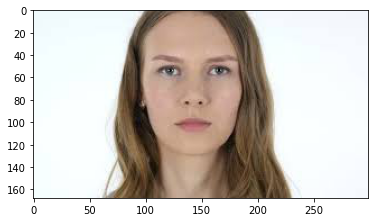

In [ ]:
random = 4
file = img_embedding_map[tuple(data[random])]
img = mpimg.imread(file)
imgplot = plt.imshow(img)
plt.show()

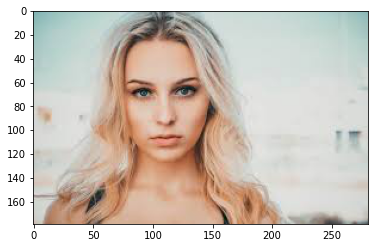

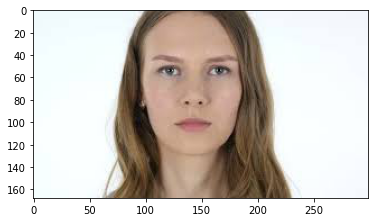

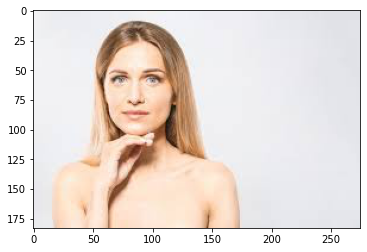

In [ ]:
predicted_cluster = km.predict([data[random]])[0]
indexes = np.where(km.labels_ == predicted_cluster)[0]
for i in indexes:
  file = img_embedding_map[tuple(data[i])]
  img = mpimg.imread(file)
  imgplot = plt.imshow(img)
  plt.show()

#Expirementation

In [10]:
def cos_sim(A,B):
  return np.dot(A,B)/(norm(A)*norm(B))

In [ ]:
# women
embeddings = extract_all_embeddings("expression_women.jpg")
len(embeddings)

6

In [ ]:
baseline = extract_embedding("neutral_face_women.jpg")
for embedding in embeddings:
  print(cos_sim(baseline,embedding))

0.9686878069420374
0.9749562095101731
0.9545858212695191
0.9738585506790177
0.9486851435866727
0.9820375271387386


In [ ]:
embeddings = extract_all_embeddings("expression_men.jpg")
len(embeddings)

7

In [ ]:
baseline = extract_embedding("neutral_face_men.jpg")
for embedding in embeddings:
  print(cos_sim(baseline,embedding))

0.940362580758063
0.9399780764269252
0.9493891246248131
0.9826589942677723
0.9561829673412896
0.9420714865361431
0.9241253593031685


In [ ]:
embeddings = extract_all_embeddings("different_angles.png")
len(embeddings)

7

In [ ]:
baseline = extract_embedding("frontal_orientation.png")
for embedding in embeddings:
  print(cos_sim(baseline,embedding))

0.9702327413436317
0.9655370663755481
0.9577206434281947
0.9795222655820665
0.9530553801269006
0.9558862201344527
0.9165705225961176


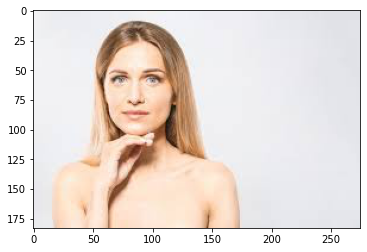

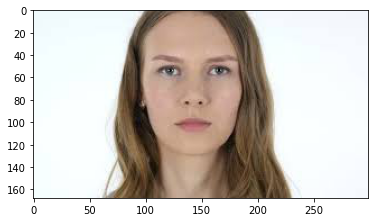

0.9045710221058062

In [ ]:
file = img_embedding_map[tuple(data[4])]
img = mpimg.imread(file)
imgplot = plt.imshow(img)
plt.show()
file1 = img_embedding_map[tuple(data[3])]
img = mpimg.imread(file1)
imgplot = plt.imshow(img)
plt.show()
cos_sim(extract_embedding(file),extract_embedding(file1))

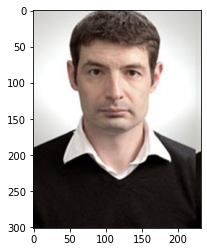

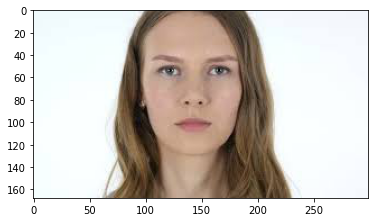

0.8295322152137539

In [16]:
file = "neutral_face_men.jpg"
img = mpimg.imread(file)
imgplot = plt.imshow(img)
plt.show()
file1 = img_embedding_map[tuple(data[3])]
img = mpimg.imread(file1)
imgplot = plt.imshow(img)
plt.show()
cos_sim(extract_embedding(file),extract_embedding(file1))